In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

from src.models.spatialgcn_baseline import SpatialGCNModel

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from src.utils.constants import *

epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = 12, prediction_horizon=4)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = range(2,3))
epidata_nuts2.finalize()

epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts2_bn  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
epidata_nuts2_gm1 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
epidata_nuts2_gm2 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()


# epidata_nuts3 = GNNDataLoader('influenza', data_env, nuts_level='nuts3', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = 12, prediction_horizon=4)
# epidata_nuts3.add_time_features()
# epidata_nuts3.log_transform_target()
# epidata_nuts3.set_splits()
# epidata_nuts3.normalize()
# epidata_nuts3.add_lagged_features(lags = range(2,3))
# epidata_nuts3.finalize()

# epidata_nuts3_id  = epidata_nuts3.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
# epidata_nuts3_bn  = epidata_nuts3.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
# epidata_nuts3_gm1 = epidata_nuts3.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
# epidata_nuts3_gm2 = epidata_nuts3.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-09-14 (+15 weeks)


2020-02-03 00:00:00


/home/de-schrijvers/projects/germany_gnn/src/models/_basemodel.py:198: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


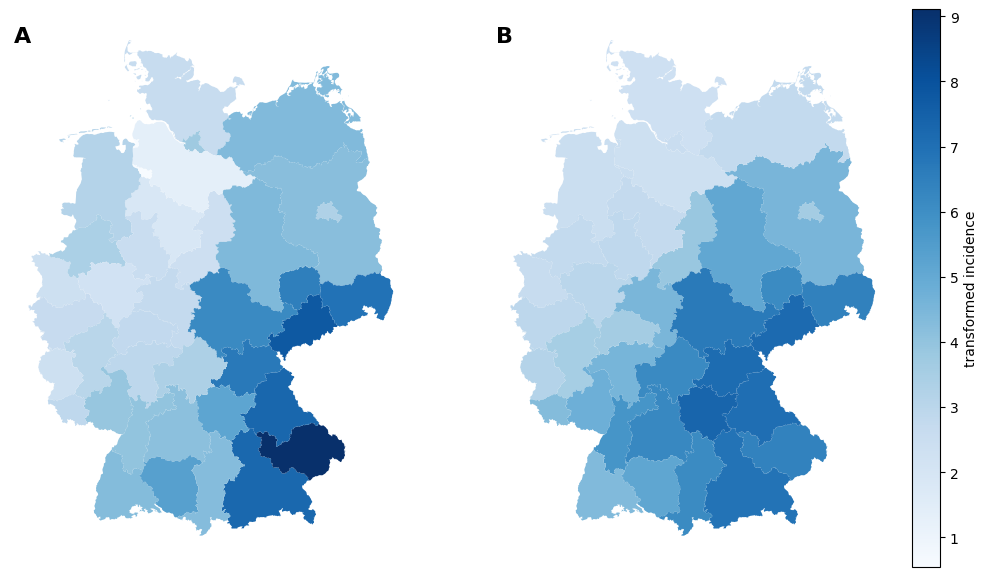

In [7]:
fig,ax =ml_trial.show_forecasts_maps('test', 35,'equal', target_h=0)

In [4]:
fig.savefig('results/annual_review_influenza_maps.png')  # replace with your desired filename and extension


## Preview dataloader

Note that this spatial model sees significantly less! Only the final (well, first) period is used.

<EpiDataLoader(disease=influenza,
data stages: ['context', 'raw', 'processed', 'processed_split', 'normalized', 'final', 'final-horizon'], 
features: ['population_size', 'timestamp_sin', 'timestamp_cos', 'incidence_lag2'], 
nuts_level=nuts2, 
date_range=(2006-05-15 - 2020-09-14), 
nodes=38, data_rows=28424
split summary: train / val / test: 85.8% / 7.1% / 7.1% (original timespan)

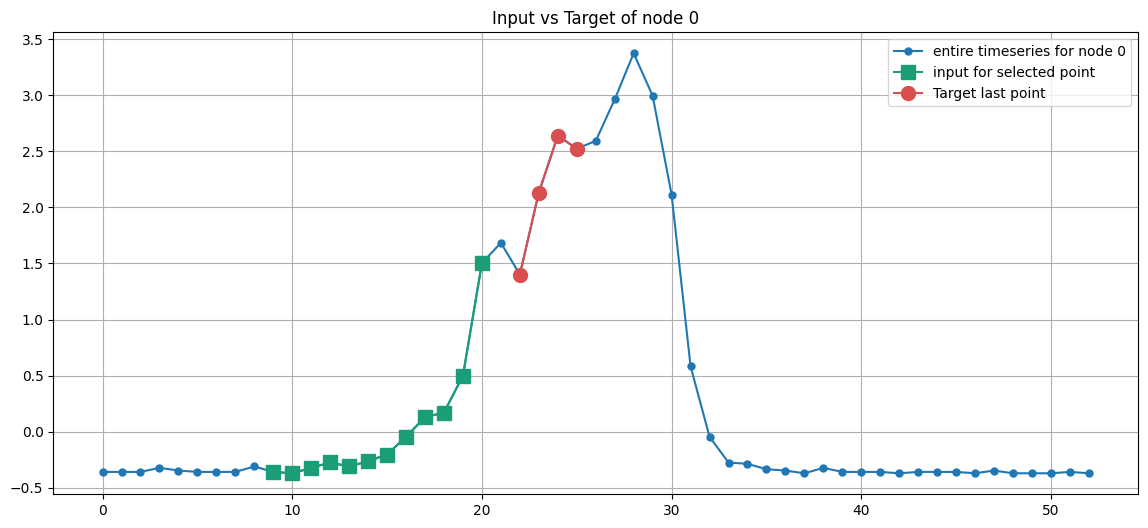

In [2]:
epidata_nuts2_id.preview_dataloader(0)

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 4], edge_index=[2, 38], edge_weight=[38])
Epoch 1 train loss: 0.5150, val loss: 0.9177 ✓ (new best)
Epoch 2 train loss: 0.4903, val loss: 0.8390 ✓ (new best)
Epoch 3 train loss: 0.4737, val loss: 0.7732 ✓ (new best)
Epoch 4 train loss: 0.4614, val loss: 0.7156 ✓ (new best)
Epoch 5 train loss: 0.4519, val loss: 0.6688 ✓ (new best)
Epoch 6 train loss: 0.4447, val loss: 0.6299 ✓ (new best)
Epoch 7 train loss: 0.4386, val loss: 0.5979 ✓ (new best)
Epoch 8 train loss: 0.4339, val loss: 0.5710 ✓ (new best)
Epoch 9 train loss: 0.4300, val loss: 0.5489 ✓ (new best)
Epoch 10 train loss: 0.4266, val loss: 0.5319 ✓ (new best)
Epoch 11 train loss: 0.4233, val loss: 0.5155 ✓ (new best)
Epoch 12 tra

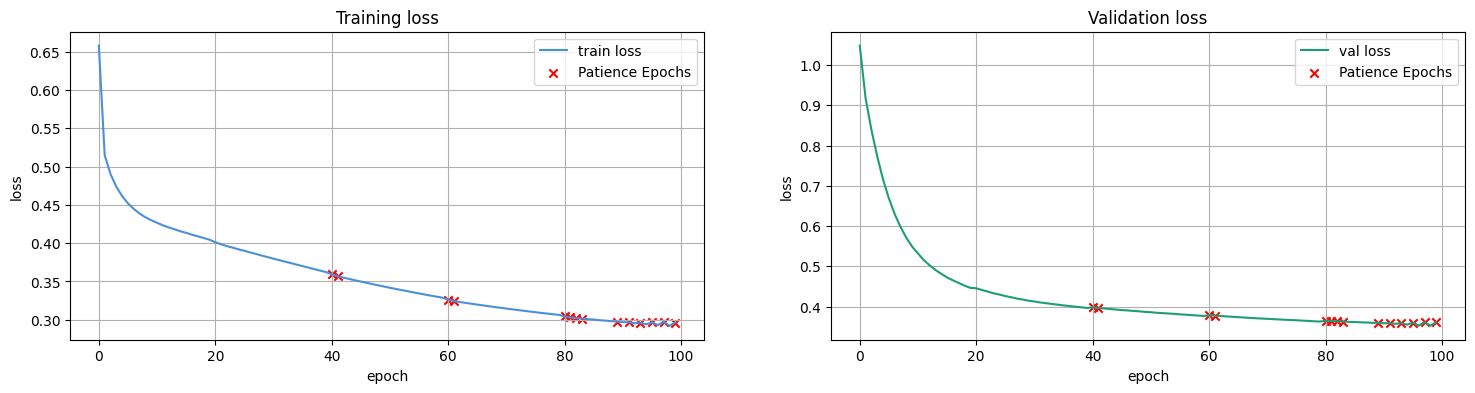

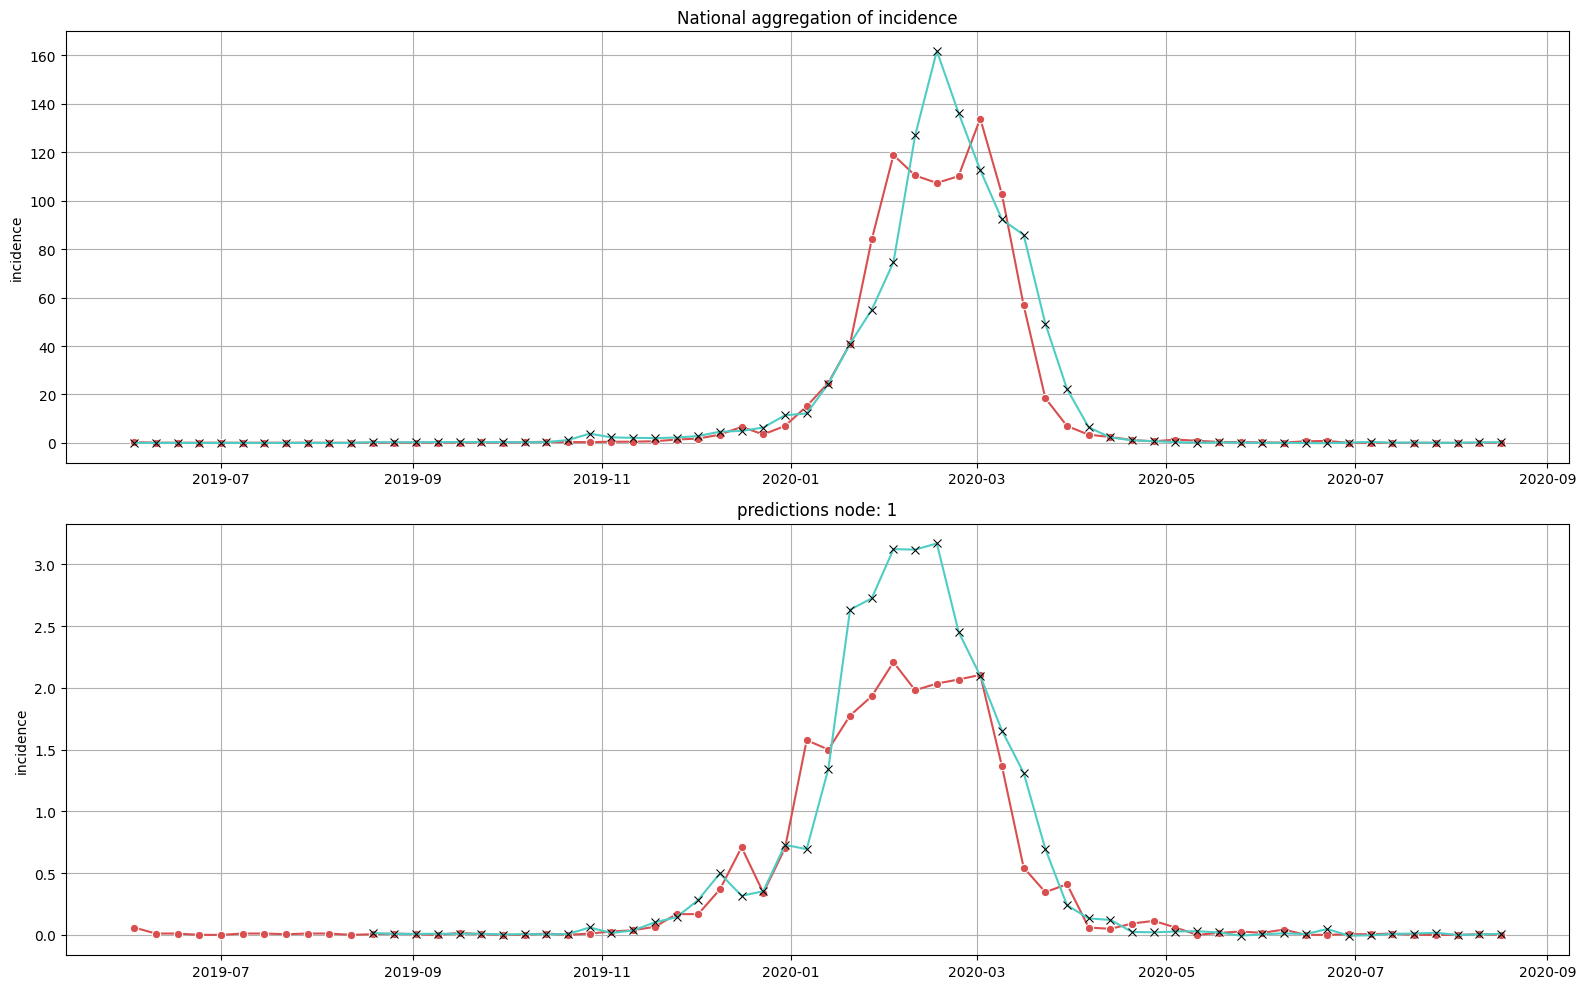

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 4], edge_index=[2, 172], edge_weight=[172])
Epoch 1 train loss: 0.5528, val loss: 1.0457 ✓ (new best)
Epoch 2 train loss: 0.5241, val loss: 0.9577 ✓ (new best)
Epoch 3 train loss: 0.5053, val loss: 0.8849 ✓ (new best)
Epoch 4 train loss: 0.4919, val loss: 0.8239 ✓ (new best)
Epoch 5 train loss: 0.4817, val loss: 0.7746 ✓ (new best)
Epoch 6 train loss: 0.4736, val loss: 0.7349 ✓ (new best)
Epoch 7 train loss: 0.4672, val loss: 0.6988 ✓ (new best)
Epoch 8 train loss: 0.4618, val loss: 0.6719 ✓ (new best)
Epoch 9 train loss: 0.4571, val loss: 0.6492 ✓ (new best)
Epoch 10 train loss: 0.4529, val loss: 0.6302 ✓ (new best)
Epoch 11 train loss: 0.4492, val loss: 0.6144 ✓ (new best)
Epoch 12 t

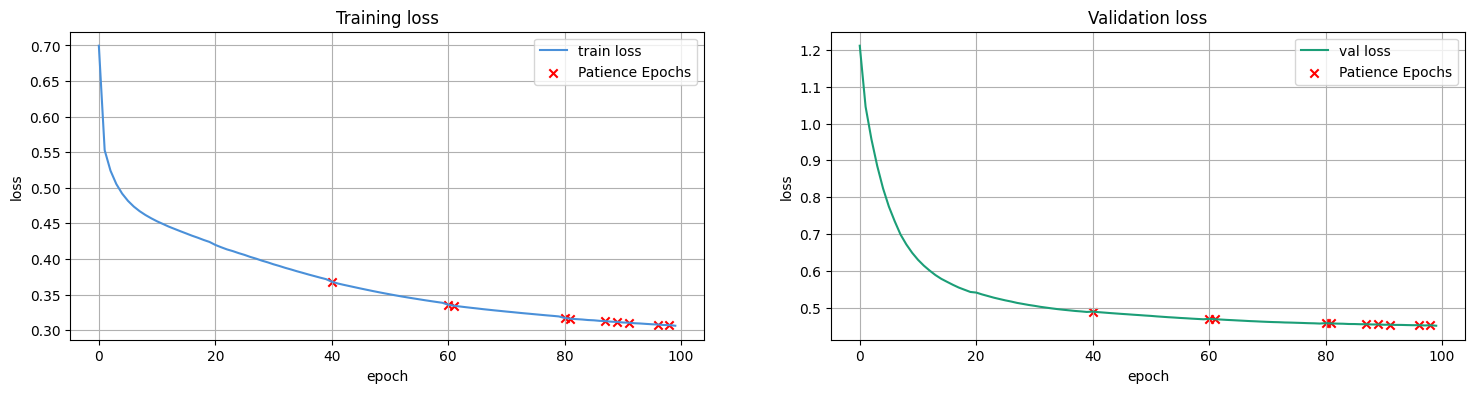

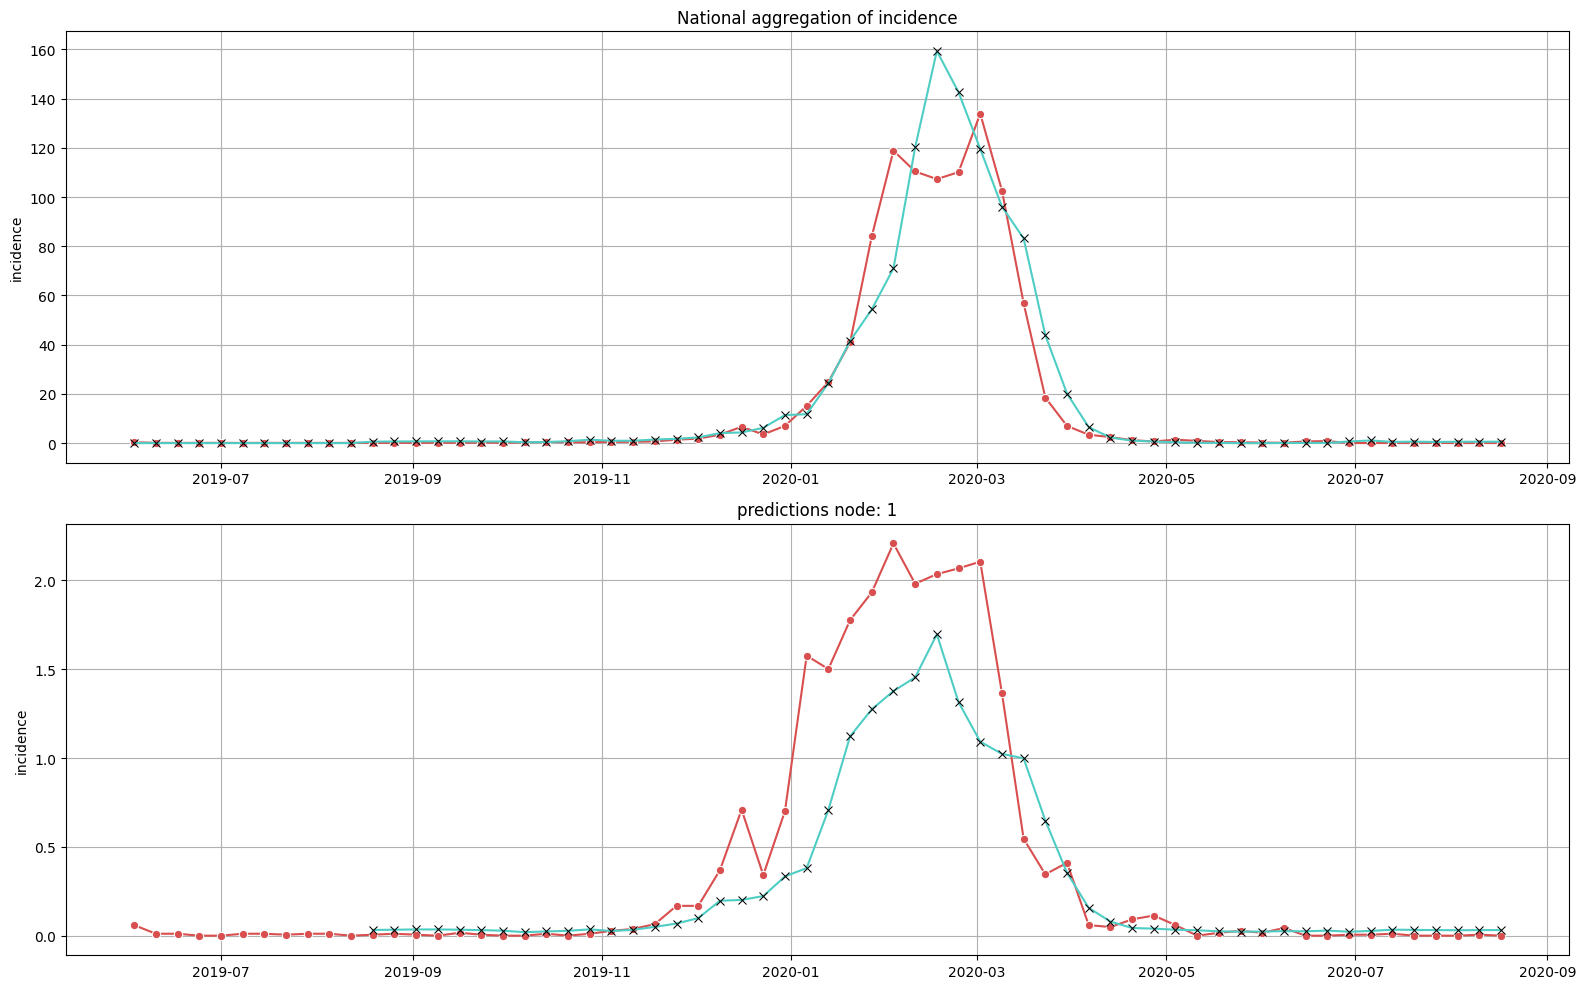

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 4], edge_index=[2, 544], edge_weight=[544])
Epoch 1 train loss: 0.5947, val loss: 1.1296 ✓ (new best)
Epoch 2 train loss: 0.5675, val loss: 1.0497 ✓ (new best)
Epoch 3 train loss: 0.5509, val loss: 0.9887 ✓ (new best)
Epoch 4 train loss: 0.5380, val loss: 0.9384 ✓ (new best)
Epoch 5 train loss: 0.5285, val loss: 0.8948 ✓ (new best)
Epoch 6 train loss: 0.5212, val loss: 0.8604 ✓ (new best)
Epoch 7 train loss: 0.5151, val loss: 0.8322 ✓ (new best)
Epoch 8 train loss: 0.5103, val loss: 0.8092 ✓ (new best)
Epoch 9 train loss: 0.5063, val loss: 0.7903 ✓ (new best)
Epoch 10 train loss: 0.5026, val loss: 0.7749 ✓ (new best)
Epoch 11 train loss: 0.4995, val loss: 0.7599 ✓ (new best)
Epoch 12 t

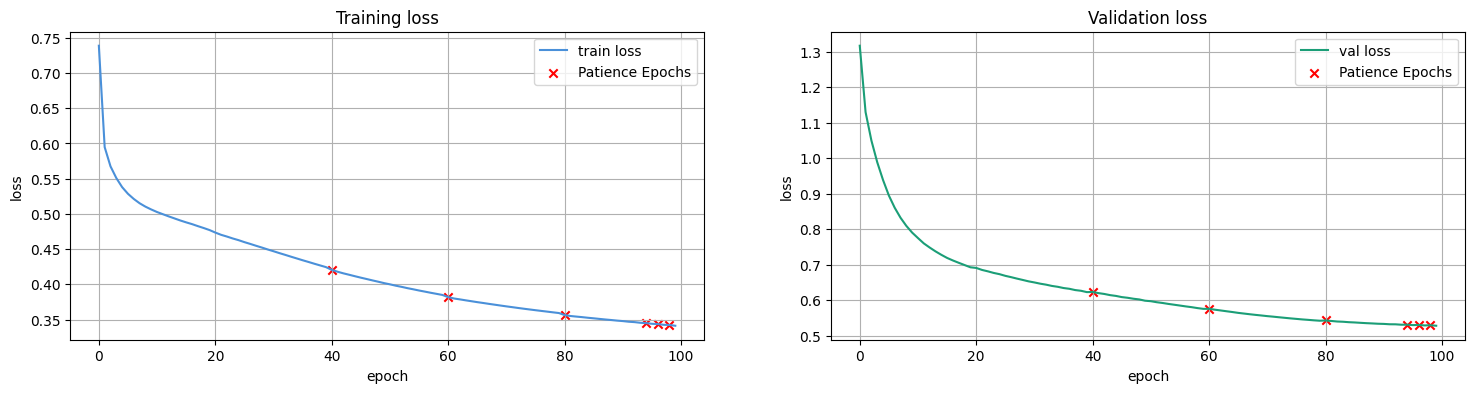

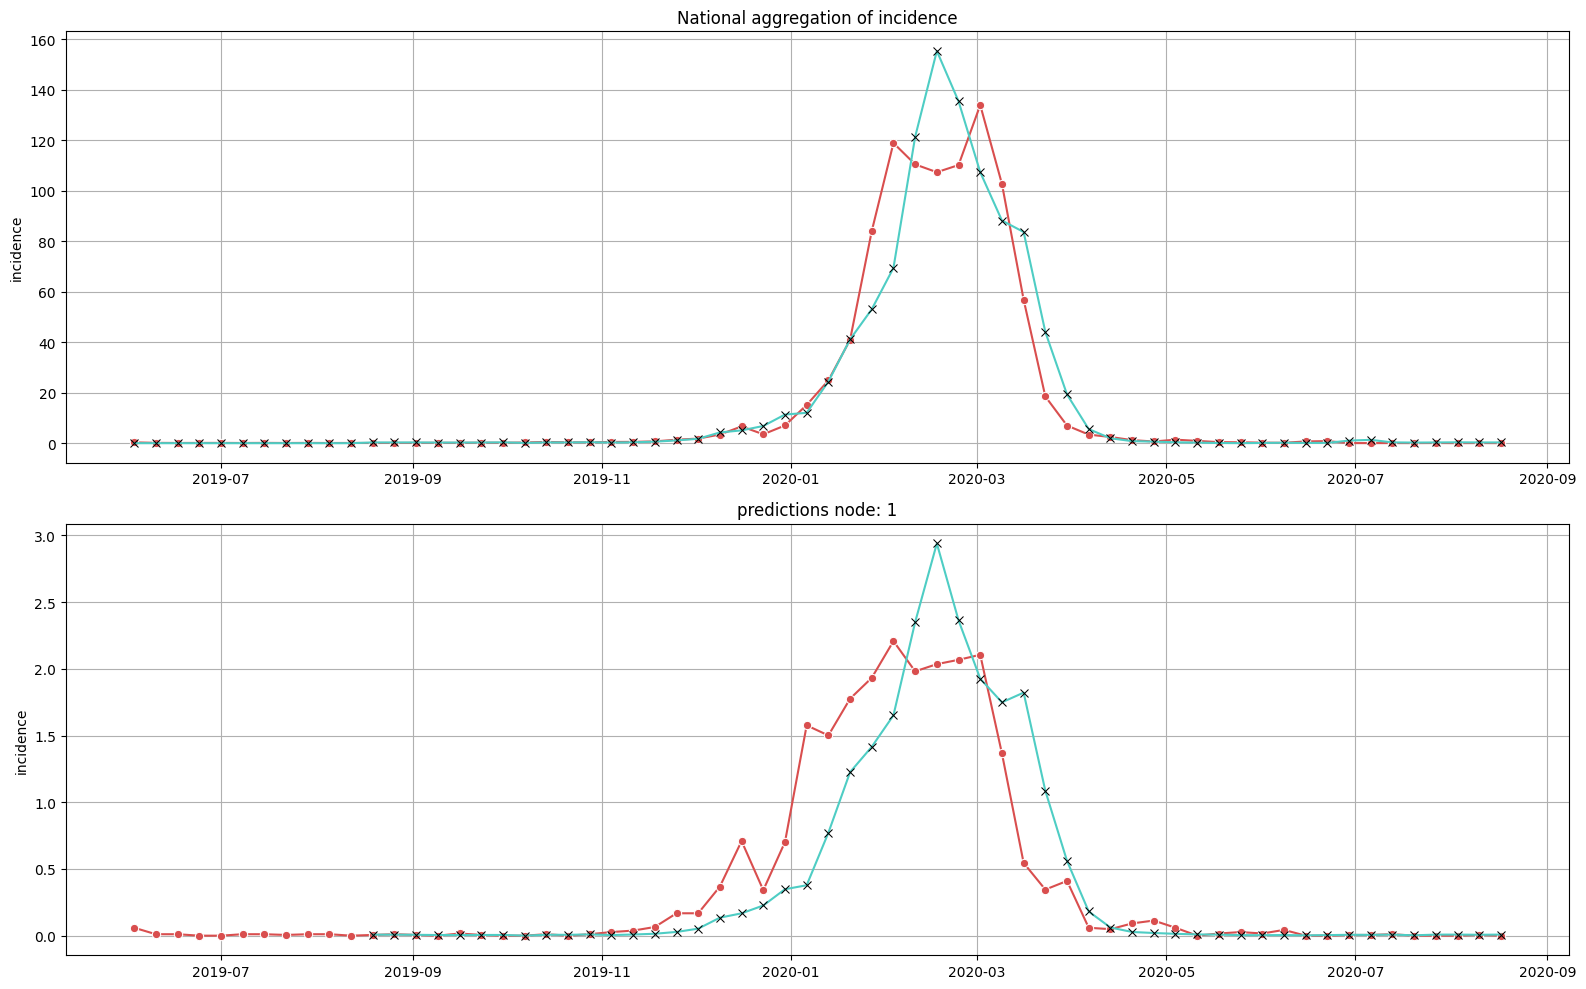

⚠️  Input features are 3D (e.g., sequences). Only the last dimension will be used (flattened).

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 4], edge_index=[2, 224], edge_weight=[224])
Epoch 1 train loss: 0.5573, val loss: 0.9996 ✓ (new best)
Epoch 2 train loss: 0.5277, val loss: 0.9220 ✓ (new best)
Epoch 3 train loss: 0.5096, val loss: 0.8627 ✓ (new best)
Epoch 4 train loss: 0.4967, val loss: 0.8136 ✓ (new best)
Epoch 5 train loss: 0.4861, val loss: 0.7727 ✓ (new best)
Epoch 6 train loss: 0.4787, val loss: 0.7378 ✓ (new best)
Epoch 7 train loss: 0.4726, val loss: 0.7093 ✓ (new best)
Epoch 8 train loss: 0.4675, val loss: 0.6850 ✓ (new best)
Epoch 9 train loss: 0.4637, val loss: 0.6651 ✓ (new best)
Epoch 10 train loss: 0.4600, val loss: 0.6490 ✓ (new best)
Epoch 11 train loss: 0.4568, val loss: 0.6351 ✓ (new best)
Epoch 12 t

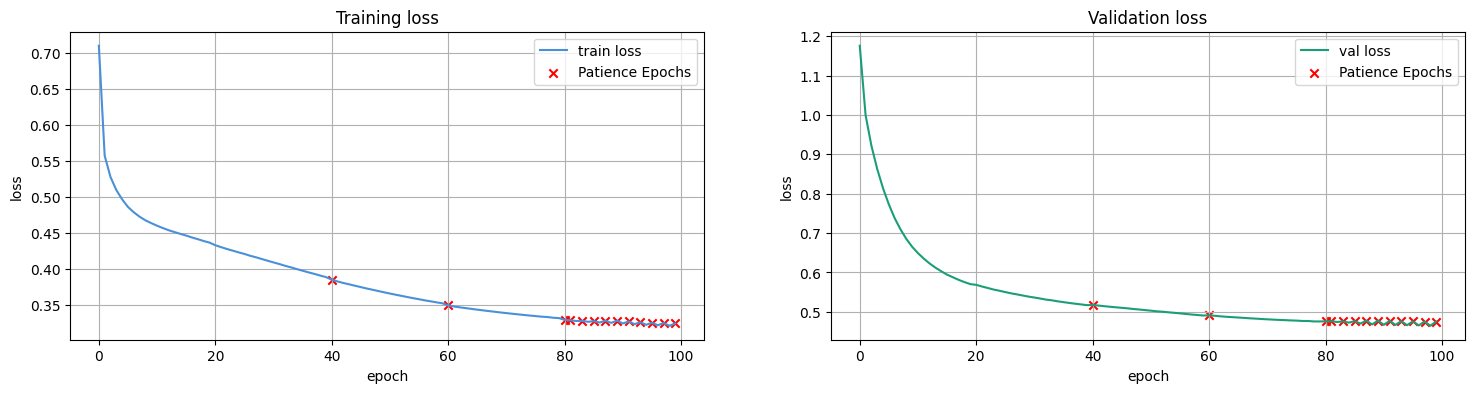

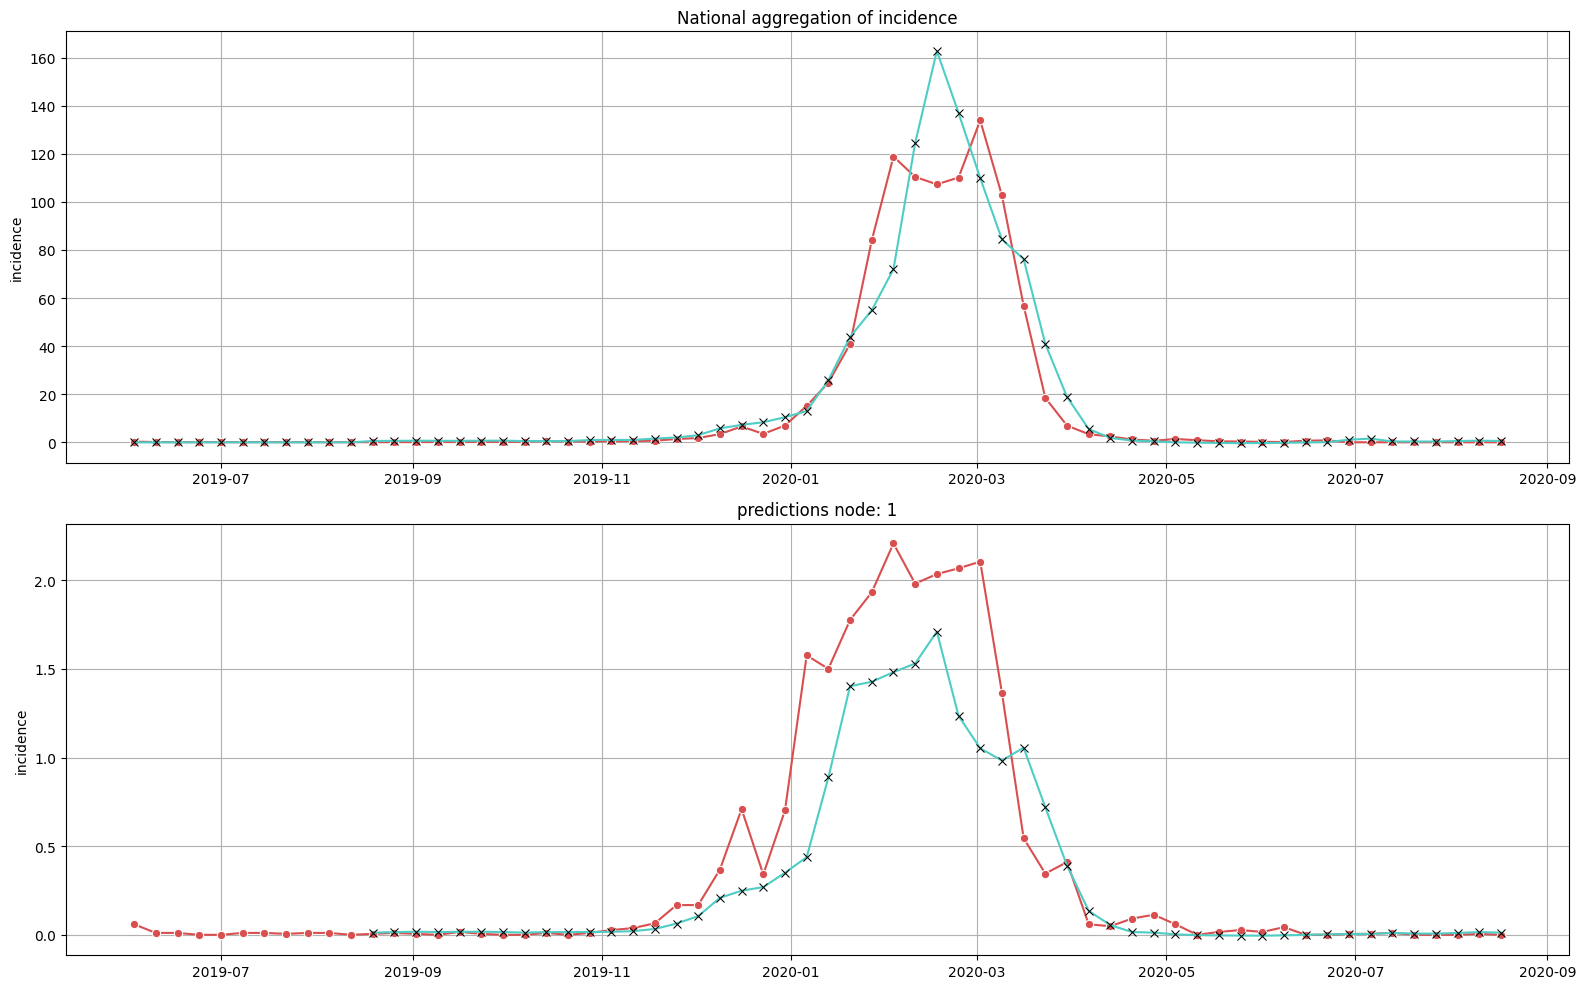

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 1'}, ylabel='incidence'>],
       dtype=object))

In [3]:
n_epochs = 100
lr       = 0.0001

ml1_id = SpatialGCNModel(name = f'baseline_spatial_gcn-identity_graph', dataloader=epidata_nuts2_id)
ml1_id.set_model_hparams()
ml1_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_id.run_snapshot(debug=True)
ml1_id.train(verbose=2)
ml1_id.forecast()
ml1_id.show_forecasts(dataset='test', target_h = 0)

ml1_bn = SpatialGCNModel(name = f'baseline_spatial_gcn-boolean_neighbors', dataloader=epidata_nuts2_bn)
ml1_bn.set_model_hparams()
ml1_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_bn.run_snapshot(debug=True)
ml1_bn.train(verbose=2)
ml1_bn.forecast()
ml1_bn.show_forecasts(dataset='test', target_h = 0)

ml1_gm1 = SpatialGCNModel(name = f'baseline_spatial_gcn-gravity_model_dense', dataloader=epidata_nuts2_gm1)
ml1_gm1.set_model_hparams()
ml1_gm1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_gm1.run_snapshot(debug=True)
ml1_gm1.train(verbose=2)
ml1_gm1.forecast()
ml1_gm1.show_forecasts(dataset='test', target_h = 0)


ml1_gm2 = SpatialGCNModel(name = f'baseline_spatial_gcn-gravity_model_sparse', dataloader=epidata_nuts2_gm2)
ml1_gm2.set_model_hparams()
ml1_gm2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1_gm2.run_snapshot(debug=True)
ml1_gm2.train(verbose=2)
ml1_gm2.forecast()
ml1_gm2.show_forecasts(dataset='test', target_h = 0)


In [6]:
ml1_id.save_model()
ml1_id.save_weights()
ml1_gm1.save_model()
ml1_gm1.save_weights()
ml1_gm2.save_model()
ml1_gm2.save_weights()
ml1_bn.save_model()
ml1_bn.save_weights()

✓ Config saved: baseline_spatial_gcn-identity_graph -> baseline_spatial_gcn_identity_graph.yaml (ID: 0001)
✓ Weights saved: config/checkpoints/0001.pt
✓ Config saved: baseline_spatial_gcn-gravity_model_dense -> baseline_spatial_gcn_gravity_model_dense.yaml (ID: 0002)
✓ Weights saved: config/checkpoints/0002.pt
✓ Config saved: baseline_spatial_gcn-gravity_model_sparse -> baseline_spatial_gcn_gravity_model_sparse.yaml (ID: 0003)
✓ Weights saved: config/checkpoints/0003.pt
✓ Config saved: baseline_spatial_gcn-boolean_neighbors -> baseline_spatial_gcn_boolean_neighbors.yaml (ID: 0004)
✓ Weights saved: config/checkpoints/0004.pt


'config/checkpoints/0004.pt'

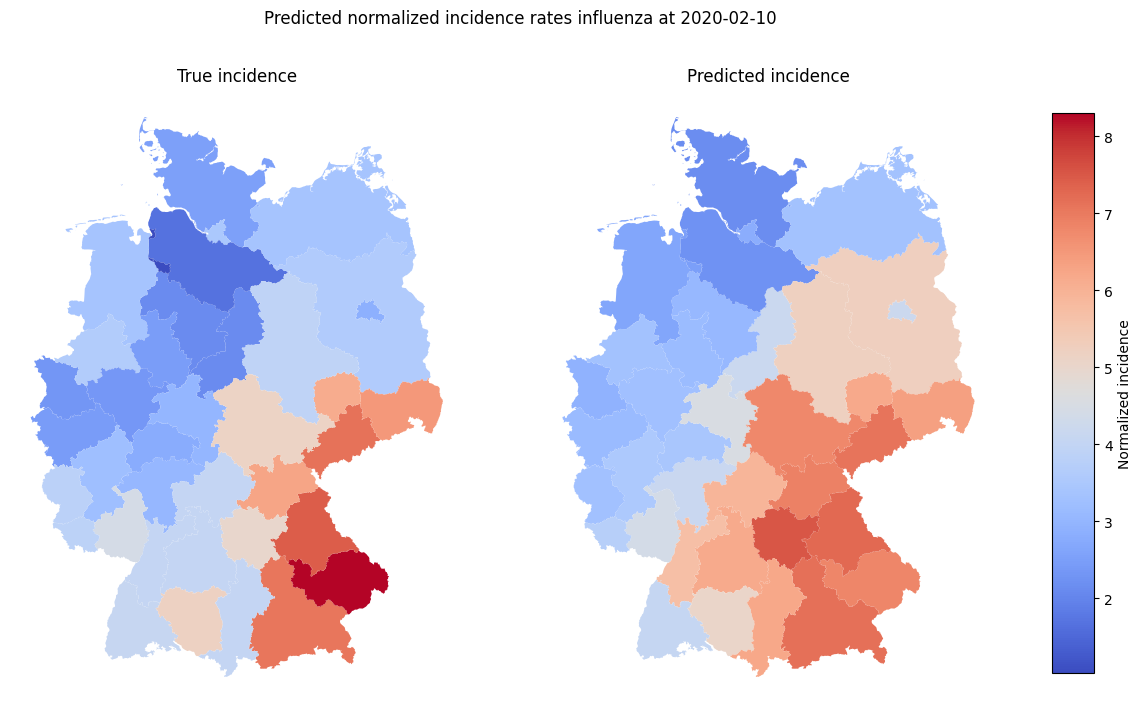

In [36]:
show_forecasts_maps(ml1, 'test', 36, 'equal')